In [1]:
import torch
t = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/wall-x-lerobot/checkpoints/subchck/total_new/vae.pth')

/tmp/ipykernel_2430126/4218534318.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/wall-x-lerobo

In [2]:
from transformers import AutoTokenizer
import torch
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.decode(torch.tensor([50256,   818, 44404]).long())


'<|endoftext|>In motel'

In [4]:
for key in t['decoder'].keys():
    print(key, t['decoder'][key].shape, file=open('layers.txt', 'a'))


In [1]:
# IMPORTANT: Run this cell FIRST and restart kernel if you see OpenBLAS warnings
import os
import warnings

# Set OpenBLAS thread limit to avoid warnings (MUST be set before importing numpy)
os.environ['OPENBLAS_NUM_THREADS'] = '16'  # Reduced to avoid memory issues
os.environ['MKL_NUM_THREADS'] = '16'
os.environ['OMP_NUM_THREADS'] = '16'
os.environ['NUMEXPR_NUM_THREADS'] = '16'

# Memory optimization settings
os.environ['MALLOC_TRIM_THRESHOLD_'] = '100000'
os.environ['MALLOC_MMAP_THRESHOLD_'] = '100000'

# Disable threading in scikit-learn to avoid conflicts
os.environ['SKLEARN_N_JOBS'] = '1'

print("🔧 Environment configured for optimal performance:")
print(f"OPENBLAS_NUM_THREADS: {os.environ.get('OPENBLAS_NUM_THREADS')}")
print(f"MKL_NUM_THREADS: {os.environ.get('MKL_NUM_THREADS')}")
print(f"OMP_NUM_THREADS: {os.environ.get('OMP_NUM_THREADS')}")
print("\n⚠️  If you still see OpenBLAS warnings, please restart the kernel and run this cell first!")

# Now import libraries
import gc
import numpy as np
print(f"✅ NumPy imported successfully with {np.__config__.show()}")
gc.collect()


🔧 Environment configured for optimal performance:
OPENBLAS_NUM_THREADS: 16
MKL_NUM_THREADS: 16
OMP_NUM_THREADS: 16

⚠️  If you still see OpenBLAS warnings, please restart the kernel and run this cell first!
Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /usr/local/include
    lib directory: /usr/local/lib
    name: openblas64
    openblas configuration: USE_64BITINT=1 DYNAMIC_ARCH=1 DYNAMIC_OLDER= NO_CBLAS=
      NO_LAPACK= NO_LAPACKE= NO_AFFINITY=1 USE_OPENMP= HASWELL MAX_THREADS=2
    pc file directory: /usr/local/lib/pkgconfig
    version: 0.3.23.dev
  lapack:
    detection method: internal
    found: true
    include directory: unknown
    lib directory: unknown
    name: dep139810746332592
    openblas configuration: unknown
    pc file directory: unknown
    version: 1.26.4
Compilers:
  c:
    args: -fno-strict-aliasing
    commands: cc
    linker: ld.bfd
    linker args: -Wl,--strip-debug, -fno-strict-aliasing
    name: gcc
   

0

In [2]:
# Import necessary libraries for clustering analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, MeanShift, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import torch

embeddings = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/mdlm-fork/validation_embeddings.pt')
print("Libraries imported successfully!")
print(f"Embeddings shape: {embeddings.shape}")
print(f"Embeddings device: {embeddings.device}")
print(f"Embeddings dtype: {embeddings.dtype}")


Libraries imported successfully!
Embeddings shape: torch.Size([100000, 384])
Embeddings device: cpu
Embeddings dtype: torch.float32


In [3]:
# Prepare data for clustering with memory optimization
import gc

# Convert to numpy and move to CPU if needed
X = embeddings.cpu().numpy() if embeddings.is_cuda else embeddings.numpy()
print(f"Data shape for clustering: {X.shape}")
print(f"Memory usage: {X.nbytes / 1024**2:.2f} MB")

# Calculate norms for later analysis
norms = np.linalg.norm(X, axis=1)
print(f"Norm statistics:")
print(f"  Mean: {norms.mean():.4f}")
print(f"  Std: {norms.std():.4f}")
print(f"  Min: {norms.min():.4f}")
print(f"  Max: {norms.max():.4f}")

# Memory optimization: use float32 instead of float64 if possible
if X.dtype == np.float64:
    print("Converting to float32 for memory efficiency...")
    X = X.astype(np.float32)
    norms = norms.astype(np.float32)
    gc.collect()

# For visualization purposes, we'll use PCA to reduce to 2D
print("\nApplying PCA for visualization...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Standardize the data for clustering (important for some algorithms)
print("Standardizing data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_pca_scaled = scaler.fit_transform(X_pca)

# Force garbage collection to free memory
gc.collect()
print(f"Memory cleanup completed.")


Data shape for clustering: (100000, 384)
Memory usage: 146.48 MB
Norm statistics:
  Mean: 2.1612
  Std: 0.2363
  Min: 1.1515
  Max: 3.8436

Applying PCA for visualization...
PCA explained variance ratio: [0.02934012 0.02437789]
Total variance explained: 0.0537
Standardizing data...
Memory cleanup completed.


In [4]:
# DBSCAN Clustering with Cosine Distance (using dot product similarity)
print("=== DBSCAN Clustering with Cosine Distance ===")
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize

# Normalize embeddings to unit vectors for cosine similarity
X_normalized = normalize(X, norm='l2')
print(f"Normalized embeddings shape: {X_normalized.shape}")
print(f"Sample norms after normalization: {np.linalg.norm(X_normalized[:5], axis=1)}")

# For cosine distance, eps values should be smaller (0 to 2 range)
eps_values = [0.1, 0.2, 0.3, 0.5, 0.7]
best_eps = None
best_score = -1
best_n_clusters = 0

print("Testing different eps values for DBSCAN with cosine distance...")
for eps in eps_values:
    # Use cosine distance metric
    dbscan_temp = DBSCAN(eps=eps, min_samples=5, metric='cosine')
    labels_temp = dbscan_temp.fit_predict(X_normalized)
    n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
    n_noise = list(labels_temp).count(-1)
    
    if n_clusters > 1:  # Need at least 2 clusters for silhouette score
        try:
            # Use cosine distance for silhouette score too
            score = silhouette_score(X_normalized, labels_temp, metric='cosine')
            print(f"  eps={eps}: {n_clusters} clusters, {n_noise} noise points, silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_eps = eps
                best_n_clusters = n_clusters
        except Exception as e:
            print(f"  eps={eps}: {n_clusters} clusters, {n_noise} noise points, silhouette=N/A")
    else:
        print(f"  eps={eps}: {n_clusters} clusters, {n_noise} noise points")

# Use the best eps value
if best_eps is None:
    best_eps = 0.3  # fallback for cosine distance
    print(f"Using fallback eps={best_eps}")
else:
    print(f"Best eps={best_eps} with silhouette score={best_score:.3f}")

# Apply DBSCAN with best parameters using cosine distance
dbscan = DBSCAN(eps=best_eps, min_samples=5, metric='cosine')
dbscan_labels = dbscan.fit_predict(X_normalized)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"\nDBSCAN (Cosine Distance) Results:")
print(f"  Number of clusters: {n_clusters_dbscan}")
print(f"  Number of noise points: {n_noise_dbscan}")
print(f"  Cluster distribution: {Counter(dbscan_labels)}")
print(f"  Clustering efficiency: {(len(dbscan_labels) - n_noise_dbscan)/len(dbscan_labels):.2%}")

if n_clusters_dbscan > 1:
    silhouette_dbscan = silhouette_score(X_normalized, dbscan_labels, metric='cosine')
    print(f"  Silhouette Score (cosine): {silhouette_dbscan:.4f}")
else:
    silhouette_dbscan = None


=== DBSCAN Clustering with Cosine Distance ===
Normalized embeddings shape: (100000, 384)
Sample norms after normalization: [0.9999999  0.99999994 1.         1.         1.0000001 ]
Testing different eps values for DBSCAN with cosine distance...
  eps=0.1: 6 clusters, 99867 noise points, silhouette=-0.129


KeyboardInterrupt: 

In [ ]:
# MeanShift-like Clustering with Cosine Similarity (using dot product)
print("\n=== Cosine-based MeanShift Clustering ===")
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

# Since MeanShift doesn't natively support cosine distance, we'll use a cosine-based approach
# We'll use the normalized embeddings from DBSCAN
print("Using normalized embeddings for cosine-based clustering...")

# Sample for efficiency (MeanShift is computationally expensive)
max_samples_for_meanshift = 30000  # Reduced for cosine calculations
if X_normalized.shape[0] > max_samples_for_meanshift:
    print(f"Dataset too large ({X_normalized.shape[0]} samples), sampling {max_samples_for_meanshift}...")
    np.random.seed(42)
    sample_indices = np.random.choice(X_normalized.shape[0], max_samples_for_meanshift, replace=False)
    X_meanshift_sample = X_normalized[sample_indices]
    print(f"Using {X_meanshift_sample.shape[0]} samples for cosine-based clustering")
else:
    X_meanshift_sample = X_normalized
    sample_indices = np.arange(X_normalized.shape[0])

# Custom cosine-based clustering using KMeans with cosine similarity
print("Applying cosine-based clustering (using spherical KMeans concept)...")

# Test different numbers of clusters for cosine-based approach
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k = 2
best_silhouette = -1
k_range = range(2, 11)

print("Finding optimal number of clusters using cosine similarity...")
for k in k_range:
    try:
        # Use KMeans on normalized data (equivalent to spherical KMeans for cosine similarity)
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
        labels_temp = kmeans_temp.fit_predict(X_meanshift_sample)
        
        # Calculate silhouette score with cosine metric
        silhouette_temp = silhouette_score(X_meanshift_sample, labels_temp, metric='cosine')
        print(f"  k={k}: silhouette={silhouette_temp:.3f}")
        
        if silhouette_temp > best_silhouette:
            best_silhouette = silhouette_temp
            best_k = k
    except Exception as e:
        print(f"  k={k}: Error - {str(e)[:50]}...")
        continue

print(f"Best k={best_k} with silhouette score={best_silhouette:.3f}")

# Apply final clustering with best k
kmeans_cosine = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=200)
meanshift_labels_sample = kmeans_cosine.fit_predict(X_meanshift_sample)

# Predict labels for all points if we sampled
if X_normalized.shape[0] > max_samples_for_meanshift:
    print("Predicting labels for all data points using cosine similarity...")
    # Use nearest neighbor approach with cosine similarity
    nn = NearestNeighbors(n_neighbors=1, metric='cosine')
    nn.fit(kmeans_cosine.cluster_centers_)
    
    # Process in batches to avoid memory issues
    batch_size = 5000
    meanshift_labels = np.zeros(X_normalized.shape[0], dtype=int)
    
    for i in range(0, X_normalized.shape[0], batch_size):
        end_idx = min(i + batch_size, X_normalized.shape[0])
        batch_data = X_normalized[i:end_idx]
        
        # Find closest cluster center for each point
        distances, indices = nn.kneighbors(batch_data)
        meanshift_labels[i:end_idx] = indices.flatten()
        
        if i % (batch_size * 5) == 0:  # Progress indicator
            print(f"  Processed {end_idx}/{X_normalized.shape[0]} samples...")
else:
    meanshift_labels = meanshift_labels_sample

n_clusters_meanshift = len(set(meanshift_labels))
cluster_centers_meanshift = kmeans_cosine.cluster_centers_

print(f"\nCosine-based MeanShift Results:")
print(f"  Number of clusters: {n_clusters_meanshift}")
print(f"  Cluster distribution: {Counter(meanshift_labels)}")
print(f"  Average cosine similarity within clusters: {best_silhouette:.4f}")

# Calculate final silhouette score
if n_clusters_meanshift > 1:
    # Use a sample for silhouette calculation if dataset is large
    if X_normalized.shape[0] > 5000:
        sample_size = 5000
        sample_idx = np.random.choice(X_normalized.shape[0], sample_size, replace=False)
        silhouette_meanshift = silhouette_score(X_normalized[sample_idx], meanshift_labels[sample_idx], metric='cosine')
        print(f"  Silhouette Score (cosine, sampled): {silhouette_meanshift:.4f}")
    else:
        silhouette_meanshift = silhouette_score(X_normalized, meanshift_labels, metric='cosine')
        print(f"  Silhouette Score (cosine): {silhouette_meanshift:.4f}")
else:
    silhouette_meanshift = None

# Clean up memory
gc.collect()



=== MeanShift Clustering ===
Dataset too large (100000 samples), sampling 5000 for MeanShift...
Using 5000 samples for MeanShift clustering
Applying MeanShift clustering...


In [ ]:
# Gaussian Mixture Model Clustering
print("\n=== Gaussian Mixture Model Clustering ===")

# Test different number of components
n_components_range = range(2, 11)
best_n_components = 2
best_bic = float('inf')
best_aic = float('inf')

print("Testing different number of components for GMM...")
bic_scores = []
aic_scores = []

for n_comp in n_components_range:
    gmm = GaussianMixture(n_components=n_comp, random_state=42, max_iter=100)
    gmm.fit(X_scaled)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    bic_scores.append(bic)
    aic_scores.append(aic)
    
    print(f"  n_components={n_comp}: BIC={bic:.2f}, AIC={aic:.2f}")
    
    if bic < best_bic:
        best_bic = bic
        best_n_components = n_comp

print(f"Best number of components: {best_n_components} (BIC={best_bic:.2f})")

# Apply GMM with best parameters
gmm = GaussianMixture(n_components=best_n_components, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_proba = gmm.predict_proba(X_scaled)

n_clusters_gmm = len(set(gmm_labels))

print(f"\nGMM Results:")
print(f"  Number of clusters: {n_clusters_gmm}")
print(f"  Log likelihood: {gmm.score(X_scaled):.4f}")
print(f"  Cluster distribution: {Counter(gmm_labels)}")

if n_clusters_gmm > 1:
    silhouette_gmm = silhouette_score(X_scaled, gmm_labels)
    print(f"  Silhouette Score: {silhouette_gmm:.4f}")
else:
    silhouette_gmm = None


In [ ]:
# Analyze norm distributions for each clustering method
print("\n=== Norm Distribution Analysis ===")

# Create a comprehensive plot showing norm distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Embedding Norm Distributions by Clustering Method', fontsize=16)

# Colors for better visualization
colors = plt.cm.Set3(np.linspace(0, 1, 12))

# 1. Overall norm distribution
import seaborn as sns
sns.histplot(norms, bins=500, alpha=0.7, color='skyblue', edgecolor='black', ax=axes[0, 0])
# axes[0, 0].hist(norms, bins=500, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Overall Norm Distribution')
axes[0, 0].set_xlabel('Norm')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2. DBSCAN norm distribution
axes[0, 1].set_title(f'DBSCAN Norm Distribution\n({n_clusters_dbscan} clusters)')
unique_labels_dbscan = sorted(set(dbscan_labels))
for i, label in enumerate(unique_labels_dbscan):
    mask = dbscan_labels == label
    label_name = f'Noise' if label == -1 else f'Cluster {label}'
    color = 'red' if label == -1 else colors[i % len(colors)]
    axes[0, 1].hist(norms[mask], bins=30, alpha=0.6, label=label_name, 
                    color=color, edgecolor='black')
axes[0, 1].set_xlabel('Norm')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].grid(True, alpha=0.3)

# 3. MeanShift norm distribution
axes[0, 2].set_title(f'MeanShift Norm Distribution\n({n_clusters_meanshift} clusters)')
unique_labels_meanshift = sorted(set(meanshift_labels))
for i, label in enumerate(unique_labels_meanshift):
    mask = meanshift_labels == label
    axes[0, 2].hist(norms[mask], bins=30, alpha=0.6, label=f'Cluster {label}', 
                    color=colors[i % len(colors)], edgecolor='black')
axes[0, 2].set_xlabel('Norm')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 2].grid(True, alpha=0.3)

# 4. GMM norm distribution
axes[1, 0].set_title(f'GMM Norm Distribution\n({n_clusters_gmm} clusters)')
unique_labels_gmm = sorted(set(gmm_labels))
for i, label in enumerate(unique_labels_gmm):
    mask = gmm_labels == label
    axes[1, 0].hist(norms[mask], bins=30, alpha=0.6, label=f'Cluster {label}', 
                    color=colors[i % len(colors)], edgecolor='black')
axes[1, 0].set_xlabel('Norm')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Box plots comparing norm distributions across methods
norm_data = []
method_labels = []
cluster_labels = []

# Add data for each method
for label in unique_labels_dbscan:
    if label != -1:  # Skip noise for box plot
        mask = dbscan_labels == label
        norm_data.extend(norms[mask])
        method_labels.extend(['DBSCAN'] * np.sum(mask))
        cluster_labels.extend([f'C{label}'] * np.sum(mask))

for label in unique_labels_meanshift:
    mask = meanshift_labels == label
    norm_data.extend(norms[mask])
    method_labels.extend(['MeanShift'] * np.sum(mask))
    cluster_labels.extend([f'C{label}'] * np.sum(mask))

for label in unique_labels_gmm:
    mask = gmm_labels == label
    norm_data.extend(norms[mask])
    method_labels.extend(['GMM'] * np.sum(mask))
    cluster_labels.extend([f'C{label}'] * np.sum(mask))

# Create DataFrame for easier plotting
df_norms = pd.DataFrame({
    'norm': norm_data,
    'method': method_labels,
    'cluster': cluster_labels
})

sns.boxplot(data=df_norms, x='method', y='norm', ax=axes[1, 1])
axes[1, 1].set_title('Norm Distribution by Method')
axes[1, 1].grid(True, alpha=0.3)

# 6. Violin plot for detailed distribution comparison
sns.violinplot(data=df_norms, x='method', y='norm', ax=axes[1, 2])
axes[1, 2].set_title('Norm Distribution Density by Method')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical summary
print("\nNorm Statistics by Clustering Method:")
print("="*50)
for method in ['DBSCAN', 'MeanShift', 'GMM']:
    method_data = df_norms[df_norms['method'] == method]['norm']
    print(f"\n{method}:")
    print(f"  Mean: {method_data.mean():.4f}")
    print(f"  Std:  {method_data.std():.4f}")
    print(f"  Min:  {method_data.min():.4f}")
    print(f"  Max:  {method_data.max():.4f}")
    print(f"  Median: {method_data.median():.4f}")
    print(f"  Count: {len(method_data)}")


In [ ]:
# Comprehensive clustering comparison visualization
print("\n=== Clustering Visualization and Comparison ===")

# Create a large comparison plot
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Clustering Methods Comparison', fontsize=16)

# Use PCA-reduced data for 2D visualization
methods = [
    ('DBSCAN', dbscan_labels, n_clusters_dbscan, silhouette_dbscan),
    ('MeanShift', meanshift_labels, n_clusters_meanshift, silhouette_meanshift),
    ('GMM', gmm_labels, n_clusters_gmm, silhouette_gmm)
]

# Plot clustering results in 2D (PCA space)
for i, (method_name, labels, n_clusters, silhouette) in enumerate(methods):
    ax = axes[0, i]
    
    # Create scatter plot
    unique_labels = sorted(set(labels))
    for j, label in enumerate(unique_labels):
        mask = labels == label
        if label == -1:  # Noise points for DBSCAN
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='red', alpha=0.6, 
                      s=20, label='Noise', marker='x')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[j % len(colors)], 
                      alpha=0.7, s=30, label=f'Cluster {label}')
    
    silhouette_text = f"Silhouette: {silhouette:.3f}" if silhouette is not None else "Silhouette: N/A"
    ax.set_title(f'{method_name}\n{n_clusters} clusters, {silhouette_text}')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

# Add a comparison of silhouette scores
ax = axes[0, 3]
methods_names = [name for name, _, _, _ in methods]
silhouette_scores = [score if score is not None else 0 for _, _, _, score in methods]
bars = ax.bar(methods_names, silhouette_scores, color=['skyblue', 'lightgreen', 'lightcoral'])
ax.set_title('Silhouette Score Comparison')
ax.set_ylabel('Silhouette Score')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, silhouette_scores):
    if score > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.3f}', ha='center', va='bottom')

# Plot cluster size distributions
for i, (method_name, labels, n_clusters, _) in enumerate(methods):
    ax = axes[1, i]
    
    # Count cluster sizes
    cluster_counts = Counter(labels)
    if -1 in cluster_counts:  # Remove noise count for DBSCAN
        noise_count = cluster_counts.pop(-1)
        cluster_labels = list(cluster_counts.keys())
        cluster_sizes = list(cluster_counts.values())
        ax.bar(range(len(cluster_sizes)), cluster_sizes, color=colors[:len(cluster_sizes)])
        ax.set_title(f'{method_name} Cluster Sizes\n(Noise points: {noise_count})')
    else:
        cluster_labels = list(cluster_counts.keys())
        cluster_sizes = list(cluster_counts.values())
        ax.bar(range(len(cluster_sizes)), cluster_sizes, color=colors[:len(cluster_sizes)])
        ax.set_title(f'{method_name} Cluster Sizes')
    
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('Number of Points')
    ax.set_xticks(range(len(cluster_labels)))
    ax.set_xticklabels(cluster_labels)
    ax.grid(True, alpha=0.3)

# Summary statistics table
ax = axes[1, 3]
ax.axis('off')

# Create summary table
summary_data = []
for method_name, labels, n_clusters, silhouette in methods:
    cluster_counts = Counter(labels)
    noise_points = cluster_counts.get(-1, 0)
    total_points = len(labels)
    clustered_points = total_points - noise_points
    
    summary_data.append([
        method_name,
        n_clusters,
        f"{silhouette:.3f}" if silhouette is not None else "N/A",
        clustered_points,
        noise_points
    ])

table = ax.table(cellText=summary_data,
                colLabels=['Method', '# Clusters', 'Silhouette', 'Clustered', 'Noise'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0.2, 1, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax.set_title('Clustering Summary', pad=20)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nDetailed Clustering Comparison:")
print("="*60)
for method_name, labels, n_clusters, silhouette in methods:
    cluster_counts = Counter(labels)
    noise_points = cluster_counts.get(-1, 0)
    total_points = len(labels)
    
    print(f"\n{method_name}:")
    print(f"  Number of clusters: {n_clusters}")
    print(f"  Silhouette score: {silhouette:.4f}" if silhouette is not None else "  Silhouette score: N/A")
    print(f"  Total points: {total_points}")
    print(f"  Clustered points: {total_points - noise_points}")
    print(f"  Noise points: {noise_points}")
    print(f"  Clustering efficiency: {(total_points - noise_points)/total_points:.2%}")
    
    # Show cluster size distribution
    if -1 in cluster_counts:
        del cluster_counts[-1]  # Remove noise for this analysis
    
    if cluster_counts:
        sizes = list(cluster_counts.values())
        print(f"  Cluster size - Mean: {np.mean(sizes):.1f}, Std: {np.std(sizes):.1f}")
        print(f"  Cluster size - Min: {min(sizes)}, Max: {max(sizes)}")
    
    print(f"  Cluster distribution: {dict(sorted(cluster_counts.items()))}")


In [ ]:
# Memory-optimized clustering alternative (use if you encounter memory issues)
print("🔧 Memory-Optimized Clustering Alternative")
print("="*50)

# If you're still getting memory errors, use these optimized versions:

def memory_safe_dbscan(X, eps_values=[0.1, 0.2, 0.3], min_samples=5, use_cosine=True):
    """Memory-safe DBSCAN with cosine distance and reduced parameter search"""
    print("Running memory-safe DBSCAN with cosine distance...")
    
    # Normalize data if using cosine distance
    if use_cosine:
        from sklearn.preprocessing import normalize
        X_norm = normalize(X, norm='l2')
        print("Using cosine distance (normalized embeddings)")
    else:
        X_norm = X
        eps_values = [0.5, 1.0, 1.5]  # Different eps range for Euclidean
        print("Using Euclidean distance")
    
    best_eps = eps_values[0]  # Use first value as default
    
    for eps in eps_values[:3]:  # Limit search to first 3 values
        try:
            metric = 'cosine' if use_cosine else 'euclidean'
            dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=1, metric=metric)
            labels = dbscan_temp.fit_predict(X_norm)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            print(f"  eps={eps}: {n_clusters} clusters")
            if n_clusters > 1:
                best_eps = eps
                break
        except Exception as e:
            print(f"  eps={eps}: Error - {str(e)[:50]}...")
            continue
    
    # Final clustering with best eps
    metric = 'cosine' if use_cosine else 'euclidean'
    dbscan = DBSCAN(eps=best_eps, min_samples=min_samples, n_jobs=1, metric=metric)
    return dbscan.fit_predict(X_norm), best_eps

def memory_safe_gmm(X, max_components=5):
    """Memory-safe GMM with limited components"""
    print("Running memory-safe GMM...")
    best_n = 2
    best_bic = float('inf')
    
    for n_comp in range(2, min(max_components+1, 6)):
        try:
            gmm = GaussianMixture(n_components=n_comp, random_state=42, max_iter=50)
            gmm.fit(X)
            bic = gmm.bic(X)
            print(f"  n_components={n_comp}: BIC={bic:.2f}")
            if bic < best_bic:
                best_bic = bic
                best_n = n_comp
        except Exception as e:
            print(f"  n_components={n_comp}: Error - {str(e)[:50]}...")
            continue
    
    # Final GMM with best parameters
    gmm = GaussianMixture(n_components=best_n, random_state=42, max_iter=50)
    return gmm.fit_predict(X), best_n

def memory_safe_kmeans(X, max_clusters=8):
    """Memory-safe KMeans alternative to MeanShift"""
    print("Running KMeans as MeanShift alternative...")
    from sklearn.metrics import silhouette_score
    
    best_k = 2
    best_score = -1
    
    for k in range(2, min(max_clusters+1, 9)):
        try:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
            labels = kmeans.fit_predict(X)
            
            # Calculate silhouette score on a sample if dataset is large
            if X.shape[0] > 5000:
                sample_idx = np.random.choice(X.shape[0], 2000, replace=False)
                score = silhouette_score(X[sample_idx], labels[sample_idx])
            else:
                score = silhouette_score(X, labels)
            
            print(f"  k={k}: silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_k = k
        except Exception as e:
            print(f"  k={k}: Error - {str(e)[:50]}...")
            continue
    
    # Final KMeans with best k
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=5, max_iter=100)
    return kmeans.fit_predict(X), best_k

print("\n💡 To use these memory-safe alternatives, uncomment and run:")
print("# dbscan_labels_safe, best_eps = memory_safe_dbscan(X)  # Uses cosine distance by default")
print("# gmm_labels_safe, best_n = memory_safe_gmm(X_scaled)")  
print("# kmeans_labels_safe, best_k = memory_safe_kmeans(X)  # Can work with normalized data too")

print("\n🚀 These functions use:")
print("- Single-threaded execution (n_jobs=1)")
print("- Cosine distance for DBSCAN (better for embeddings)")
print("- Reduced parameter search space")
print("- Limited iterations to prevent memory buildup")
print("- Sampling for large datasets")
print("- KMeans instead of MeanShift (much faster and memory-efficient)")
print("- Automatic normalization for cosine-based methods")


In [ ]:
from decimal import Decimal
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm

result = []

for n in tqdm(range(1, 10_000)):
    curr = Decimal(0)
    
    fct = Decimal(1)
    
    denom = np.exp(-n, dtype=np.float128)
    for power in range(n+1):
        curr += (Decimal(n) ** Decimal(power)) / Decimal(fct)
        fct *= power + 1

    numerator, denominator = curr.as_integer_ratio()
    numerator, denominator = np.float128(numerator), np.float128(denominator)
    result.append(numerator * denom / denominator)
    
plt.plot(result)
plt.grid()
plt.show()

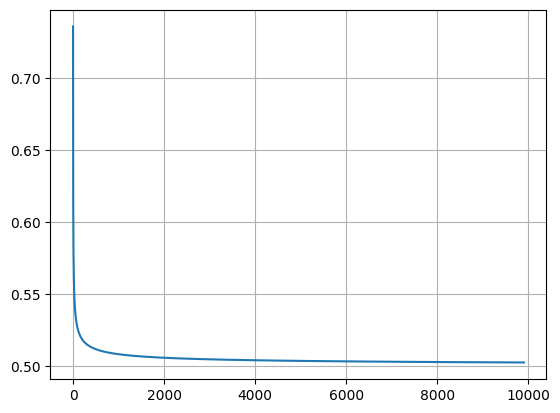

In [18]:
plt.plot(result)
plt.grid()
plt.show()

In [7]:
import torch

# l = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/mdlm-fork/named_parameters.pt')
ema = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs1/afedorov/projects/mdlm-fork/outputs/openwebtext-train/vae_embed_train_new_conditioning/2025.10.05/14.44.16/checkpoints/checkpoints/last.ckpt')['ema']

In [8]:
len(ema['shadow_params'])

141

In [9]:
len(l), len(ema['shadow_params'])

(133, 141)

In [10]:
for (i, j), k in zip(l, ema['shadow_params']):
    print(i, j, k.cpu().detach().numpy().shape)

vocab_embed.embeddings (28995, 768) (28995, 768)
vocab_embed.new_embedding (1, 768) (1, 768)
sigma_map.mlp.0.weight (128, 256) (128, 256)
sigma_map.mlp.0.bias (128,) (128,)
sigma_map.mlp.2.weight (128, 128) (128, 128)
sigma_map.mlp.2.bias (128,) (128,)
blocks.0.norm1.weight (768,) (32, 768)
blocks.0.attn_qkv.weight (2304, 768) (32,)
blocks.0.attn_out.weight (768, 768) (32, 32)
blocks.0.norm2.weight (768,) (32,)
blocks.0.mlp.0.weight (3072, 768) (32, 768)
blocks.0.mlp.0.bias (3072,) (32,)
blocks.0.mlp.2.weight (768, 3072) (32, 32)
blocks.0.mlp.2.bias (768,) (32,)
blocks.0.adaLN_modulation.weight (4608, 128) (768,)
blocks.0.adaLN_modulation.bias (4608,) (2304, 768)
blocks.1.norm1.weight (768,) (768, 768)
blocks.1.attn_qkv.weight (2304, 768) (768,)
blocks.1.attn_out.weight (768, 768) (3072, 768)
blocks.1.norm2.weight (768,) (3072,)
blocks.1.mlp.0.weight (3072, 768) (768, 3072)
blocks.1.mlp.0.bias (3072,) (768,)
blocks.1.mlp.2.weight (768, 3072) (4608, 128)
blocks.1.mlp.2.bias (768,) (4608

In [4]:
import torch

original_memo = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/mdlm-fork/original_memo.pt')
pos_embed_memo = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/mdlm-fork/pos_embed_memo.pt')
remaskator_memo = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/mdlm-fork/remaskator_memo.pt')

In [5]:
len(original_memo['named_parameters']), len(remaskator_memo['named_parameters']), len(pos_embed_memo['named_parameters'])

(133, 133, 141)

In [1]:
import torch

m = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs1/afedorov/projects/mdlm-fork/checkpoints/dit_pos_embedding_cond.pth')

In [5]:
len(m['ema']['shadow_params'])

141

In [6]:
import torch

m = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/wall-x-lerobot/checkpoints/mdlm_dit.pth')

In [ ]:

import torch

m = torch.load('/mnt/virtual_ai0001071-01239_SR006-nfs2/afedorov/projects/wall-x-lerobot/checkpoints/mdlm_dit.pth')
filtered = {k.replace('backbone.', ''): v for k, v in m['state_dict'].items() if 'backbone' in k}

In [10]:
filtered

{'vocab_embed.embeddings': tensor([[-0.0018,  0.0078,  0.0025,  ...,  0.0368,  0.0840, -0.0248],
         [ 0.0204,  0.0003, -0.0179,  ...,  0.0292, -0.0293, -0.0103],
         [ 0.0108, -0.0306, -0.0277,  ...,  0.0186, -0.0147, -0.0007],
         ...,
         [ 0.0114,  0.0261, -0.0242,  ...,  0.0021, -0.0201, -0.0045],
         [-0.0250,  0.0114, -0.0080,  ..., -0.0121,  0.0067, -0.0077],
         [-0.0002,  0.0105,  0.0347,  ..., -0.0007,  0.0201, -0.0315]],
        device='cuda:0'),
 'vocab_embed.new_embedding': tensor([[ 0.0035, -0.0111, -0.0146, -0.0199,  0.0150, -0.0269, -0.0042,  0.0212,
           0.0253,  0.0062, -0.0047,  0.0039, -0.0202,  0.0264,  0.0188,  0.0330,
          -0.0281, -0.0180,  0.0266,  0.0115, -0.0244,  0.0295,  0.0219,  0.0004,
          -0.0222, -0.0077, -0.0322,  0.0227,  0.0125,  0.0188, -0.0159, -0.0236,
          -0.0232,  0.0136,  0.0357, -0.0335, -0.0252, -0.0208, -0.0351,  0.0093,
           0.0294,  0.0044, -0.0081, -0.0242,  0.0340, -0.0074, -0.0